# Group 2: Luca Milani, Marta Laskowska, Monika Kaczorowska

### Libraries

In [714]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.figure_factory as ff 

In [715]:
import plotly.io as pio
pio.templates.default = "plotly_white"   


## Task #1: Import the data and describe the sample

### Sort the stock data by date and print the number of stocks

In [716]:
df_1 = pd.read_csv("Data_PCLab1_Stock.csv", parse_dates=["Date"])
df_1 = df_1.sort_values("Date").set_index("Date")
df_1.head()

,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
Date,,,,,,,,,
2012-01-12,60.198570,75.510002,30.120001,12.13,175.929993,180.550003,28.250000,313.644379,1295.500000
2012-01-13,59.972858,74.599998,30.070000,12.35,178.419998,179.160004,22.790001,311.328064,1289.089966
2012-01-17,60.671429,75.239998,30.250000,12.25,181.660004,180.000000,26.600000,313.116364,1293.670044
2012-01-18,61.301430,75.059998,30.330000,12.73,189.440002,181.070007,26.809999,315.273285,1308.040039
2012-01-19,61.107143,75.559998,30.420000,12.80,194.449997,180.520004,26.760000,318.590851,1314.500000


In [717]:
print("The number of stocks is ", df_1.shape[1])

The number of stocks is  9


### Check if data contains any null values

In [718]:
pd.isna(df_1)

,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
Date,,,,,,,,,
2012-01-12,False,False,False,False,False,False,False,False,False
2012-01-13,False,False,False,False,False,False,False,False,False
2012-01-17,False,False,False,False,False,False,False,False,False
2012-01-18,False,False,False,False,False,False,False,False,False
2012-01-19,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
2020-08-05,False,False,False,False,False,False,False,False,False
2020-08-06,False,False,False,False,False,False,False,False,False
2020-08-07,False,False,False,False,False,False,False,False,False


In [719]:
percent_missing = df_1.isnull().sum() * 100 / len(df_1)
missing_value_df = pd.DataFrame({'percent_missing': percent_missing})
missing_value_df

,percent_missing
AAPL,0.0
BA,0.0
T,0.0
MGM,0.0
AMZN,0.0
IBM,0.0
TSLA,0.0
GOOG,0.0
sp500,0.0


There are **no missing values** for any of the columns in the dataset across the whole period.

### What is the average market value of the S&P500?

In [720]:
df_1.describe()

,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
count,2159.000000,2159.000000,2159.000000,2159.000000,2159.000000,2159.000000,2159.000000,2159.000000,2159.000000
mean,140.819823,189.942700,35.162899,23.105743,915.665665,161.853001,259.600815,783.712512,2218.749554
std,70.827601,103.678586,3.207490,6.963847,697.838905,25.561938,210.988003,334.448057,537.321727
min,55.790001,67.239998,26.770000,7.140000,175.929993,94.769997,22.790001,278.481171,1278.040039
25%,89.165714,124.015000,33.040001,18.545000,316.490005,142.769997,184.595001,527.214416,1847.984985
50%,116.599998,142.419998,34.930000,23.780001,676.010010,156.949997,231.960007,737.599976,2106.629883
75%,175.019997,297.044998,37.419998,28.430000,1593.645019,185.974998,307.350006,1079.744995,2705.810059
max,455.609985,440.619995,43.470001,38.029999,3225.000000,215.800003,1643.000000,1568.489990,3386.149902


In [721]:
print("The average market value of S&P500 is: $", df_1['sp500'].mean())

The average market value of S&P500 is: $ 2218.7495540592868


### Which stock or index has the minimum dispersion in dollar value?

In [722]:
df_numeric = df_1.copy()

# Dispersion measures
dispersion_df = pd.DataFrame({
    "Variance": df_numeric.var(),
    "Standard Deviation": df_numeric.std(),
    "Range": df_numeric.max() - df_numeric.min(),
    "IQR": df_numeric.quantile(0.75) - df_numeric.quantile(0.25)
})

dispersion_df

,Variance,Standard Deviation,Range,IQR
AAPL,5016.549110,70.827601,399.819984,85.854283
BA,10749.249190,103.678586,373.379997,173.029998
T,10.287991,3.207490,16.700001,4.379997
MGM,48.495166,6.963847,30.889999,9.885000
AMZN,486979.137239,697.838905,3049.070007,1277.155014
IBM,653.412664,25.561938,121.030006,43.205002
TSLA,44515.937383,210.988003,1620.209999,122.755005
GOOG,111855.502794,334.448057,1290.008819,552.530579
sp500,288714.638185,537.321727,2108.109863,857.825074


In [723]:
min_disp_col = dispersion_df["Standard Deviation"].idxmin()
print(f"\nStock or Index with the minimum dispersion: {min_disp_col}")


Stock or Index with the minimum dispersion: T


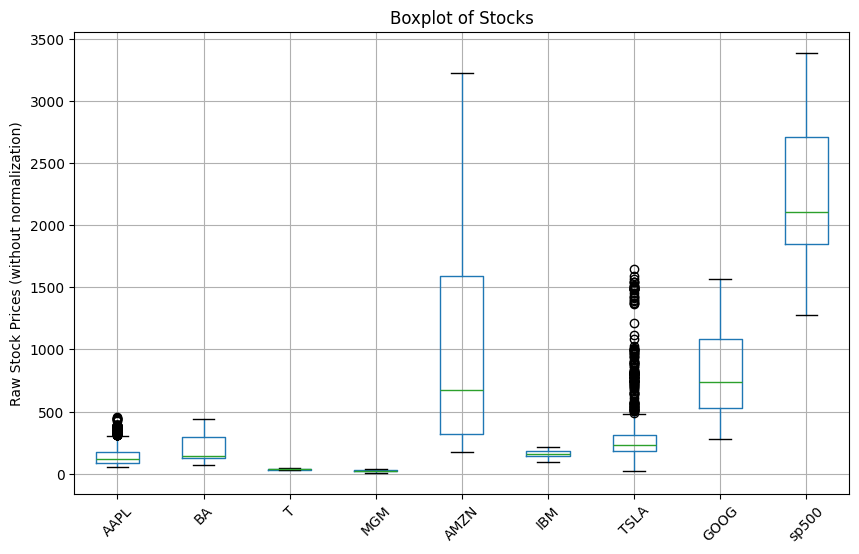

In [724]:
plt.figure(figsize=(10, 6))
df_numeric.boxplot()
plt.title("Boxplot of Stocks")
plt.ylabel("Raw Stock Prices (without normalization)")
plt.xticks(rotation=45)
plt.show()

As indicated in the boxplot above, it is visible that T stock has got minimum dispersion for raw stock prices (without normalization). This might be due to the fact that this stock has a lower price scale than the rest.

### What is the maximum price for Amazon stock over the specified time period?

In [725]:
max_idx = df_1['AMZN'].idxmax()         
max_val = df_1['AMZN'].max()            

print("The maximum value of Amazon over the specified time period is $", max_val, "noted on", max_idx.date())

The maximum value of Amazon over the specified time period is $ 3225.0 noted on 2020-08-06


## Task #2: Plot the data

### Define a function to plot the entire dataframe
The function takes in a dataframe as an input argument and does not return
anything back

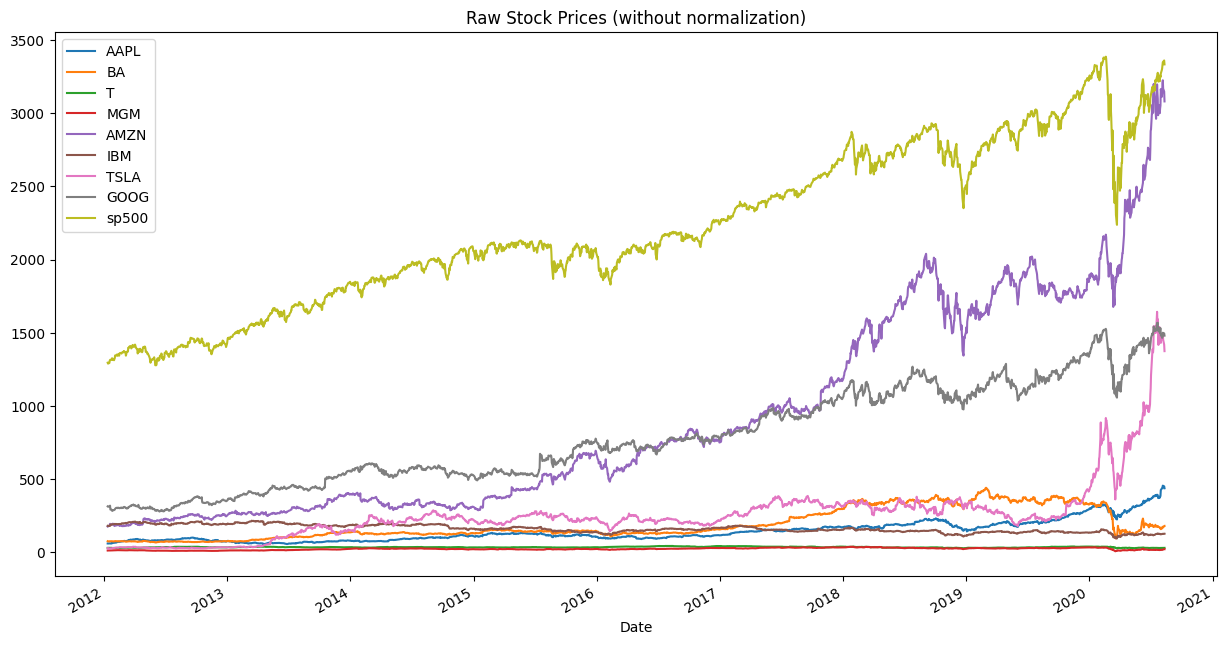

In [726]:
def plot(df):
    df_copy = df.copy()
    df_copy.plot(figsize=(15,8), title = 'Raw Stock Prices (without normalization)')

plot(df_1)

Across the whole period, Raw Stock Prices (without normalization) of S&P500 have been the highest. 

A sharp increase in prices can be noted for sp500 (S&P500), AMZN (Amazon), GOOG (Google), TSLA (Tesla) and AAPL (Apple) stocks around the first quarter of 2020.

## Task #3: Print out normalized (scaled) stock prices

### Define a function to normalize the prices based on the initial price
The function simply divides every stock by it’s price at the start date (i.e. : Date
= 2012-01-12)

In [727]:
def normalize_prices(df):
    df_norm = df.copy()
    start_row = df_norm.iloc[0]

    df_norm = df_norm / start_row
    return df_norm

In [728]:
df_1

,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
Date,,,,,,,,,
2012-01-12,60.198570,75.510002,30.120001,12.130000,175.929993,180.550003,28.250000,313.644379,1295.500000
2012-01-13,59.972858,74.599998,30.070000,12.350000,178.419998,179.160004,22.790001,311.328064,1289.089966
2012-01-17,60.671429,75.239998,30.250000,12.250000,181.660004,180.000000,26.600000,313.116364,1293.670044
2012-01-18,61.301430,75.059998,30.330000,12.730000,189.440002,181.070007,26.809999,315.273285,1308.040039
2012-01-19,61.107143,75.559998,30.420000,12.800000,194.449997,180.520004,26.760000,318.590851,1314.500000
...,...,...,...,...,...,...,...,...,...
2020-08-05,440.250000,174.279999,29.850000,16.719999,3205.030029,125.449997,1485.020020,1473.609985,3327.770020
2020-08-06,455.609985,172.199997,29.840000,18.459999,3225.000000,126.120003,1489.579956,1500.099976,3349.159912
2020-08-07,444.450012,170.020004,30.020000,19.030001,3167.459961,124.959999,1452.709961,1494.489990,3351.280029


### Plot normalized data


In [729]:
normalized_df = normalize_prices(df_1)
normalized_df.head()

,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
Date,,,,,,,,,
2012-01-12,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2012-01-13,0.996251,0.987949,0.998340,1.018137,1.014153,0.992301,0.806726,0.992615,0.995052
2012-01-17,1.007855,0.996424,1.004316,1.009893,1.032570,0.996954,0.941593,0.998317,0.998587
2012-01-18,1.018320,0.994040,1.006972,1.049464,1.076792,1.002880,0.949027,1.005193,1.009680
2012-01-19,1.015093,1.000662,1.009960,1.055235,1.105269,0.999834,0.947257,1.015771,1.014666


In [730]:
def plot(df):
    df_copy = df.copy()
    df_copy.plot(figsize=(15,8), title = 'Normalized Stock Prices')

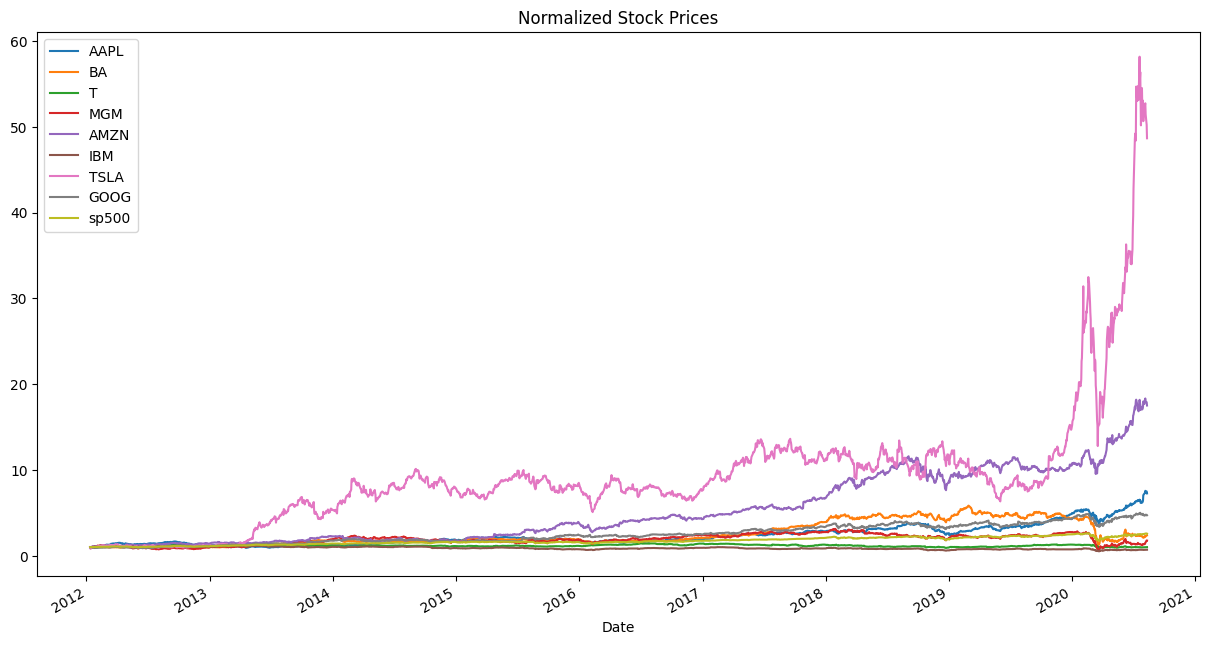

In [731]:
plot(normalized_df)

The normalization allowed to observe trends over the time period, removing differences in absolute stock price levels.

- TSLA (Tesla) shows the most dramatic growth, especially after 2019. 

- AMZN (Amazon) also displays strong long-term growth, steadily increasing over the years.

It is visible that the highest growth over the time period was achieved by tech-focused companies.

### **Optional:** Define a function to perform an interactive data plotting using plotly express

In [732]:
def interactive_plot(df):
    df_copy = df.copy()
    df_copy = df_copy.reset_index()
    
    # long-format
    df_long = df_copy.melt(id_vars="Date", var_name="Stock", value_name="Price")

    fig = px.line(
        df_long, 
        x="Date", 
        y="Price", 
        color="Stock",
        title="Normalized Stock Prices"
    )
    fig.show()

In [733]:
interactive_plot(normalized_df)

## Task #5 : Calculate stock returns

### Define a function to calculate stocks daily returns (for all stocks)
- Loop through each stock
- Loop through each row belonging to the stock

In [734]:
def daily_stock_returns(df):
    returns_df = pd.DataFrame(index=df.index) 
    
    for col in df.columns:
        returns = []
        for i in range(len(df)):
            if i == 0:
                returns.append(0.0)  # first day - no return
            else:
                prev_price = df[col].iloc[i-1]
                curr_price = df[col].iloc[i]
                daily_return_pct = ((curr_price - prev_price) / prev_price) * 100  # percentage
                returns.append(daily_return_pct)
        returns_df[col] = returns
    
    return returns_df

### Plot

<Axes: xlabel='Date'>

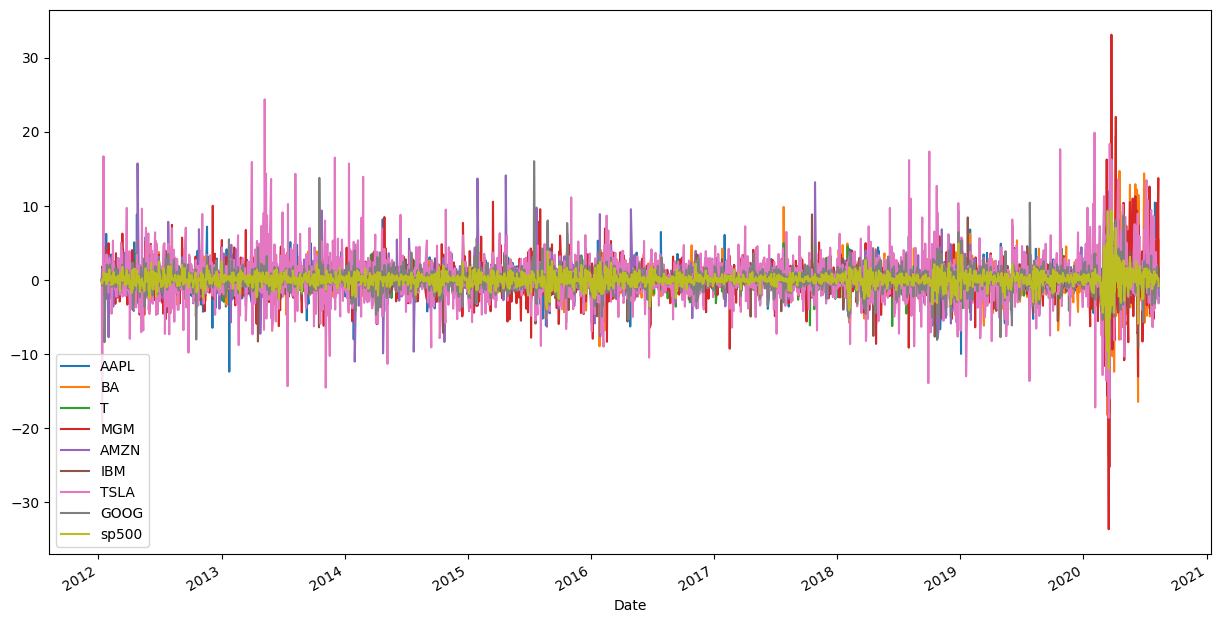

In [735]:
returns_df = daily_stock_returns(df_1)
returns_df.plot(figsize=(15,8))

Most returns are clustered around zero, reflecting small day-to-day fluctuations.

There are, however, **noticeable spikes** that represent large positive or negative returns. TSLA (Tesla) in particular exhibits **much higher volatility**, due to the fact Tesla joined the S&P500 in 2020, before hand it was a smaller cap stock associated to higher volatility. Around 2020, all stocks show **increased volatility**, consistent with the **COVID-19 outbreak**. In contrast to the other stocks, the **S&P 500 appears much smoother** and more stable, since diversification reduces overall volatility.

### Calculate the correlations between daily returns

In [736]:
correlation_matrix = returns_df.corr()
correlation_matrix

,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
AAPL,1.000000,0.385250,0.341373,0.384089,0.410234,0.434534,0.288535,0.509125,0.657321
BA,0.385250,1.000000,0.401602,0.554229,0.267466,0.479264,0.250946,0.388048,0.641826
T,0.341373,0.401602,1.000000,0.340166,0.233145,0.484219,0.152515,0.353695,0.617463
MGM,0.384089,0.554229,0.340166,1.000000,0.309016,0.441631,0.311879,0.439142,0.631449
AMZN,0.410234,0.267466,0.233145,0.309016,1.000000,0.339589,0.310084,0.575284,0.539560
IBM,0.434534,0.479264,0.484219,0.441631,0.339589,1.000000,0.245609,0.458816,0.703935
TSLA,0.288535,0.250946,0.152515,0.311879,0.310084,0.245609,1.000000,0.322805,0.387921
GOOG,0.509125,0.388048,0.353695,0.439142,0.575284,0.458816,0.322805,1.000000,0.684572
sp500,0.657321,0.641826,0.617463,0.631449,0.539560,0.703935,0.387921,0.684572,1.000000


### Plot the correlation table as in heat-map

In [737]:
correlation_matrix.style.background_gradient(cmap="coolwarm")

,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
AAPL,1.000000,0.385250,0.341373,0.384089,0.410234,0.434534,0.288535,0.509125,0.657321
BA,0.385250,1.000000,0.401602,0.554229,0.267466,0.479264,0.250946,0.388048,0.641826
T,0.341373,0.401602,1.000000,0.340166,0.233145,0.484219,0.152515,0.353695,0.617463
MGM,0.384089,0.554229,0.340166,1.000000,0.309016,0.441631,0.311879,0.439142,0.631449
AMZN,0.410234,0.267466,0.233145,0.309016,1.000000,0.339589,0.310084,0.575284,0.539560
IBM,0.434534,0.479264,0.484219,0.441631,0.339589,1.000000,0.245609,0.458816,0.703935
TSLA,0.288535,0.250946,0.152515,0.311879,0.310084,0.245609,1.000000,0.322805,0.387921
GOOG,0.509125,0.388048,0.353695,0.439142,0.575284,0.458816,0.322805,1.000000,0.684572
sp500,0.657321,0.641826,0.617463,0.631449,0.539560,0.703935,0.387921,0.684572,1.000000


As indicated by the positive correlations, most stocks move in the same direction as the broader market.
Most stocks have moderate positive correlations with the S&P 500, particularly IBM and Google.

### What are the top 2 stocks that are positively correlated with the S&P500?

In [738]:
sp_corr = correlation_matrix["sp500"].drop("sp500")
sp_corr

AAPL    0.657321
BA      0.641826
T       0.617463
MGM     0.631449
AMZN    0.539560
IBM     0.703935
TSLA    0.387921
GOOG    0.684572
Name: sp500, dtype: float64

In [739]:
print("The two stocks most correlated with S&P500 are:")
sp_corr.sort_values(ascending=False).head(2)

The two stocks most correlated with S&P500 are:


IBM     0.703935
GOOG    0.684572
Name: sp500, dtype: float64

IBM and GOOG (Google) stocks, as two stocks most correlated with the S&P500 index, have returns which tend to move very closely with the overall market. One of the reasons why this two companies could be that they have large market cap and the S&P500 is market-cap weighted, but also they are both in the tech sector which is a dominant sector in the S&P500

### What is the correlation between Amazon and Boeing? Comment on your answer

In [740]:
print("The correlation between AMZN and BA is:", correlation_matrix.loc["AMZN", "BA"])

The correlation between AMZN and BA is: 0.26746613808364744


The **correlation is relatively low (~0.27)**, which means that their stock returns don't move strongly together. 

While Amazon is a tech-oriented company, whose performance depends heavily on online retail and cloud computing, Boeing, on the other hand, is an aerospace company, whose stock is driven by airline demand and aircraft orders. Both companies **operate in different industries**, therefore their stock **prices are influenced by distinct factors**.

### What is the correlation between MGM and Boeing? Comment on your answer

In [741]:
print("The correlation between MGM and BA is:", correlation_matrix.loc["MGM", "BA"])

The correlation between MGM and BA is: 0.5542294514206465


The **correlation is moderate (~0.55)**, which means that their stock returns tend to move in the same direction, although the relationship is not exceptionally strong. 

Both companies seem to be influenced by **similar factors** such as economic growth and travel demand. While MGM operates in the hospitality and entertainment industry, its stock price heavily depends on **consumer spending and travel demand**. Similarly for Boeing in the aerospace, its stock prices are heavily tied to **global travel and economic cycles**.

### Plot the histograms of daily returns and comment

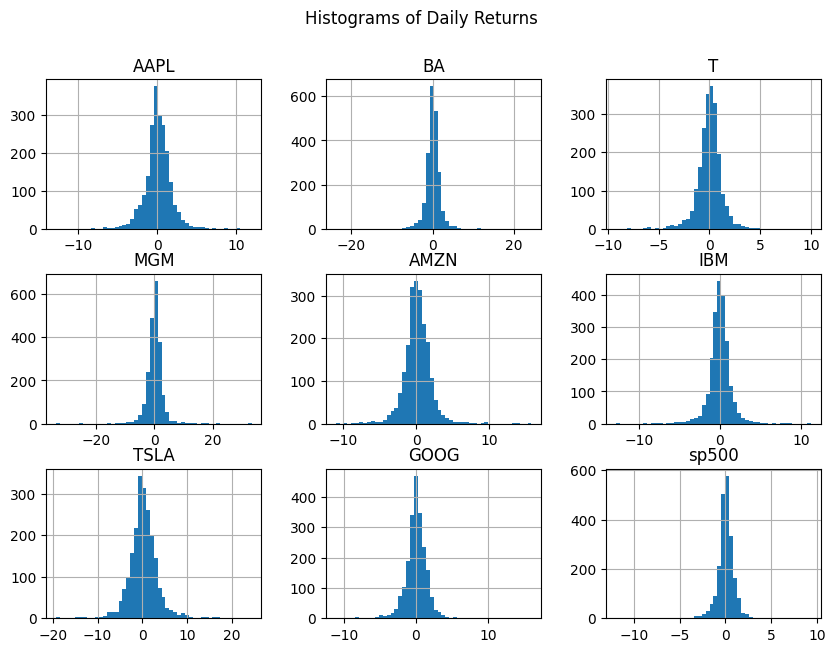

In [742]:
returns_df.hist(bins=50, figsize=(10,7))
plt.suptitle("Histograms of Daily Returns")
plt.show()

All return distributions are **centered close to zero** (bell-shaped), reflecting that on average, **daily gains and losses balance out** in the short run.

Stocks such as TSLA (Tesla), MGM (MGM Resorts International) and BA (Boeing Co) display much **wider spreads, indicating higher volatility**. While the other stocks are more **narrowly centred, reflecting lower volatility**.

The S&P 500 distribution is narrower than most individual stocks.

The above-displayed histograms highlight the **trade-off between risk and return** - growth-oriented companies, such as Tesla, show wider dispersion - allowing for high potential gains but also higher losses, while diversified assets like S&P500 show lower risk with lower potential returns.

### **Optional**: Define a function to perform an interactive and fancy histograms plots using Plotly module (figure factory module)

In [743]:
def plot_interactive_histograms(df, bins=50):
    
    for col in df.columns:
        data = [df[col].values]

        fig = ff.create_distplot(
            hist_data=data,
            group_labels=[col],
            bin_size=1.0/bins,
            show_rug=False
        )

        fig.update_layout(
            title=f"Interactive Histogram of Daily Returns: {col}",
            xaxis_title="Daily Return",
            yaxis_title="Density",
            width=800,
            height=500,
            showlegend=False
        )

        fig.show()

In [744]:
plot_interactive_histograms(returns_df)

From the interactive plots we can notice that the most frequent returns are around 0 and that they are bell shaped but with heavier tails than a normal curve, which means that they have occasionally large jumps. On the other hand, the S&P500 has thinner tails, suggesting that diversification smooths out company-specific shocks reducing therefore volatility.

## Task #6A : Portfolio weights

### Write a function that will :
– Simulate 1000 portfolios with random weights

– Compute the return, the variance and the Sharpe ratio of each portfolio

– Return the maximum Sharpe ratio and its weights

In this task, we build a function that simulates 1000 random portfolios by generating random weights across the available assets, making sure they sum to one. For each portfolio, we calculate the expected annualized return using the mean of the assets’ daily returns, multiplying by 252 to scale from daily to yearly terms (252 is the number of trading days in a year of the US stock market), and compute the volatility using the covariance matrix scaled in the same way. From these values we derive the Sharpe ratio, which measures the portfolio’s efficiency by comparing its excess return over the risk-free rate (set to zero here) relative to its risk. This process creates a “cloud” of risk-return combinations, each with a corresponding Sharpe ratio.

In [745]:
assets_df = returns_df.drop(columns=["sp500"], errors="ignore").copy()


def simulate_portfolios(returns_df, num_portfolios=1000, rf=0.0, periods_per_year=252, exclude=("sp500",)):

    returns_df = returns_df.drop(columns=list(exclude), errors="ignore").copy()

    mean_returns = returns_df.mean() * periods_per_year
    cov_matrix   = returns_df.cov()  * periods_per_year

    rets, vols, sharpes, wts = [], [], [], []

    for _ in range(num_portfolios):
        weights = np.random.random(len(returns_df.columns))
        weights /= weights.sum()

        port_ret = float(weights @ mean_returns.values)
        port_var = float(weights @ cov_matrix.values @ weights)
        port_vol = np.sqrt(port_var)
        sharpe   = (port_ret - rf) / port_vol if port_vol != 0 else 0.0

        rets.append(port_ret); vols.append(port_vol); sharpes.append(sharpe); wts.append(weights)

    best_idx = int(np.argmax(sharpes))
    best = {"sharpe": sharpes[best_idx], "return": rets[best_idx], "vol": vols[best_idx], "weights": np.array(wts[best_idx])}
    cloud = {"returns": np.array(rets), "vols": np.array(vols), "sharpes": np.array(sharpes), "weights": np.array(wts),
             "mean_returns": mean_returns, "cov_matrix": cov_matrix}
    return best, cloud


In [746]:
best, cloud = simulate_portfolios(returns_df, num_portfolios=1000, rf=0.0, periods_per_year=252)


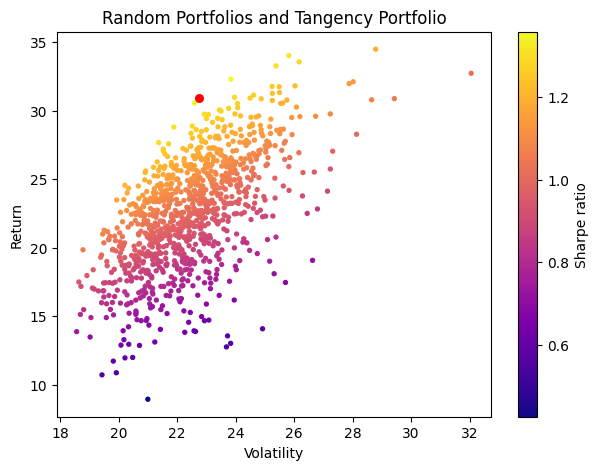

In [747]:
plt.figure(figsize=(7,5))
sc = plt.scatter(
    cloud["vols"], cloud["returns"],
    c=cloud["sharpes"], cmap="plasma", s=8
)
plt.colorbar(sc, label="Sharpe ratio")

# Tangency portfolio as a big red dot
plt.scatter(
    best["vol"], best["return"],
    marker="o", s=30, c="red",  linewidth=1.0
)

plt.xlabel("Volatility")
plt.ylabel("Return")
plt.title("Random Portfolios and Tangency Portfolio")
plt.show()


Among the simulated portfolios, the one with the maximum Sharpe ratio is identified as the tangency portfolio. This portfolio represents the best risk-return tradeoff, meaning that it delivers the highest return per unit of risk. In graphical terms, we plot all simulated portfolios as a scatterplot of return versus volatility, color-coded by Sharpe ratio. The tangency portfolio is highlighted as a red dot, clearly showing its superior position compared to the rest.


### What are the weights of your tangency portfolio? 


In [748]:
weights_series = pd.Series(best["weights"], index=assets_df.columns).sort_values(ascending=False)
print("Max Sharpe ratio:", round(best["sharpe"], 4))
print("Tangency weights:")
print(weights_series.apply(lambda x: f"{x:.2%}"))

Max Sharpe ratio: 1.3585
Tangency weights:
AMZN    27.12%
AAPL    25.35%
TSLA    15.91%
BA      14.96%
T        9.37%
GOOG     6.61%
MGM      0.42%
IBM      0.26%
dtype: object


We extracted the weights in the previous function, so we just had to return the ones of of the portfolio with the highest sharpe ratio (tangency portfolio). As we can see the highest allocation is to the stocks that had the biggest growth in 2012-2020 window (as shown in the normalized stock prices in task 3). 

### What would have been the performance of this portfolio over the sample period? Plot it!

We then calculate its cumulative performance over the sample period, showing how one dollar invested would have grown if allocated according to these optimal weights.

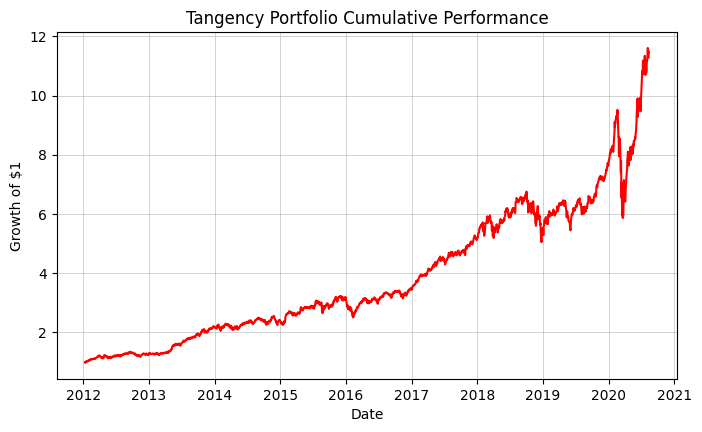

In [749]:
tangency_daily = assets_df.dot(best["weights"]) / 100  
cum_growth_tangency = (1 + tangency_daily).cumprod()

plt.figure(figsize=(8,4.5))
plt.plot(cum_growth_tangency.index, cum_growth_tangency.values, color='red')
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.title("Tangency Portfolio Cumulative Performance")
plt.grid(True, linewidth=0.4)
plt.show()

### Comparing to a baseline portfolio with equal weights for each stock

In [750]:
rf = 0.0
periods_per_year = 252

n = len(returns_df.columns)
ew_w = np.ones(n) / n

mean_ann = returns_df.mean() * periods_per_year
cov_ann  = returns_df.cov() * periods_per_year

# EW metrics
ew_ret = float(ew_w @ mean_ann.values)
ew_var = float(ew_w @ cov_ann.values @ ew_w)
ew_vol = np.sqrt(ew_var)
ew_sharpe = (ew_ret - rf) / ew_vol if ew_vol != 0 else 0.0

print("Equal-weight portfolio metrics:")
print(f"  Return (ann.):  {ew_ret:.4f}")
print(f"  Vol (ann.):     {ew_vol:.4f}")
print(f"  Sharpe (ann.):  {ew_sharpe:.4f}")
print("  Weights:")
for name, w in zip(returns_df.columns, ew_w):
    print(f"    {name}: {w:.2%}")


Equal-weight portfolio metrics:
  Return (ann.):  21.3797
  Vol (ann.):     20.9935
  Sharpe (ann.):  1.0184
  Weights:
    AAPL: 11.11%
    BA: 11.11%
    T: 11.11%
    MGM: 11.11%
    AMZN: 11.11%
    IBM: 11.11%
    TSLA: 11.11%
    GOOG: 11.11%
    sp500: 11.11%


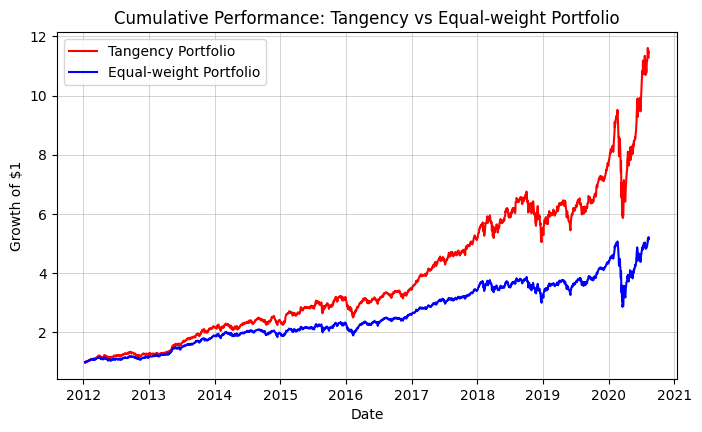

In [751]:
# Equal-weight portfolio daily return
ew_daily = returns_df.dot(ew_w) / 100
cum_growth_ew = (1 + ew_daily).cumprod()

# Plot both
plt.figure(figsize=(8,4.5))
plt.plot(cum_growth_tangency.index, cum_growth_tangency.values, label="Tangency Portfolio", color="red")
plt.plot(cum_growth_ew.index, cum_growth_ew.values, label="Equal-weight Portfolio", color="blue")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.title("Cumulative Performance: Tangency vs Equal-weight Portfolio")
plt.legend()
plt.grid(True, linewidth=0.4)
plt.show()

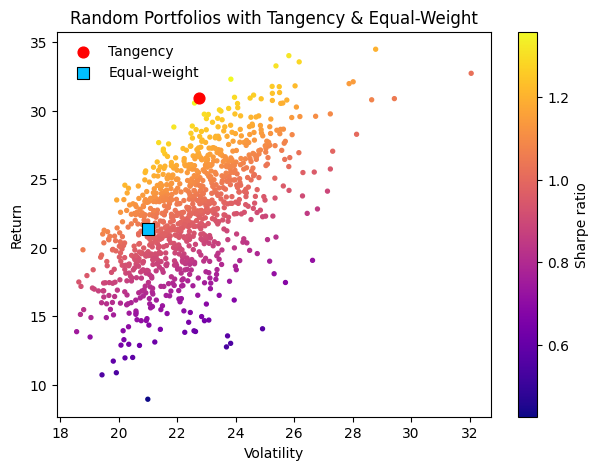

In [752]:
plt.figure(figsize=(7,5))
sc = plt.scatter(
    cloud["vols"], cloud["returns"],
    c=cloud["sharpes"], cmap="plasma", s=8
)
plt.colorbar(sc, label="Sharpe ratio")

# Tangency portfolio (red dot)
plt.scatter(best["vol"], best["return"], marker="o", s=60, c="red", label="Tangency")

# Equal-weight portfolio (blue square)
plt.scatter(ew_vol, ew_ret, marker="s", s=70, c="deepskyblue", edgecolor="k", linewidth=0.8, label="Equal-weight")

plt.xlabel("Volatility")
plt.ylabel("Return")
plt.title("Random Portfolios with Tangency & Equal-Weight")
plt.legend(frameon=False)
plt.show()

The results highlight that the tangency portfolio, with a higher Sharpe ratio, achieves a more efficient balance of risk and return than the equal-weight alternative. The growth plot further illustrates the superior performance of the tangency portfolio over time, confirming the practical advantage of using portfolio optimization methods instead of equally spreading investments across all available assets.


## Task #6B: Portfolio weights with risk free rate

### Write a function that will :
– Simulate 1000 portfolios with random weights

– Compute the return, the variance and the Sharpe ratio of each portfolio

– Return the maximum Sharpe ratio and its weights

In part B, we repeat the same procedure as in part A, simulating 1000 random portfolios, calculating their annualized returns, volatilities, and Sharpe ratios, and identifying the tangency portfolio with the highest Sharpe ratio. The key difference is that, instead of assuming a zero risk-free rate, we now incorporate the actual daily federal funds rate (DFF) from FRED (https://fred.stlouisfed.org/series/DFF) to compute excess returns more accurately. Methodologically, the simulation and optimization steps remain identical, but this adjustment grounds the Sharpe ratio in a realistic benchmark. As expected, the results are very similar to part A, since the average risk-free rate over the period is close to zero and does not materially affect portfolio rankings, just a slighlty lower Sharpe ratio.

In [753]:
# Load the DFF
rates_df = pd.read_csv("DFF.csv", parse_dates=["observation_date"])
rates_df["observation_date"] = rates_df["observation_date"].dt.normalize()
rates_df = rates_df.rename(columns={"DFF": "rf"})  

# Align by date and keep valid rf levels
aligned = assets_df.join(
    rates_df.set_index("observation_date")[["rf"]],
    how="inner"
).dropna(subset=["rf"])

In [754]:
def simulate_portfolios(returns_df, num_portfolios=1000, rf_series=None, periods_per_year=252):
    if rf_series is None:
        rf_annual = 0.0
    else:
        rf_series = rf_series.reindex(returns_df.index)
        rf_annual = rf_series.mean() 

    # Annualized mean & covariance (percent units)
    mean_returns = returns_df.mean() * periods_per_year
    cov_matrix   = returns_df.cov()  * periods_per_year

    rets, vols, sharpes, wts = [], [], [], []

    for _ in range(num_portfolios):
        weights = np.random.random(len(returns_df.columns))
        weights /= weights.sum()

        port_ret = float(weights @ mean_returns.values)
        port_var = float(weights @ cov_matrix.values @ weights)
        port_vol = np.sqrt(port_var)

        sharpe = (port_ret - rf_annual) / port_vol if port_vol != 0 else 0.0

        rets.append(port_ret); vols.append(port_vol); sharpes.append(sharpe); wts.append(weights)

    best_idx = int(np.argmax(sharpes))
    best = {
        "sharpe":  sharpes[best_idx],
        "return":  rets[best_idx],
        "vol":     vols[best_idx],
        "weights": np.array(wts[best_idx]),
    }
    cloud = {
        "returns":      np.array(rets),
        "vols":         np.array(vols),
        "sharpes":      np.array(sharpes),
        "weights":      np.array(wts),
        "mean_returns": mean_returns,
        "cov_matrix":   cov_matrix
    }
    return best, cloud

In [755]:
best, cloud = simulate_portfolios(
    aligned.drop(columns="rf"),   
    num_portfolios=1000,
    rf_series=aligned["rf"],      # daily DFF levels
    periods_per_year=252
)

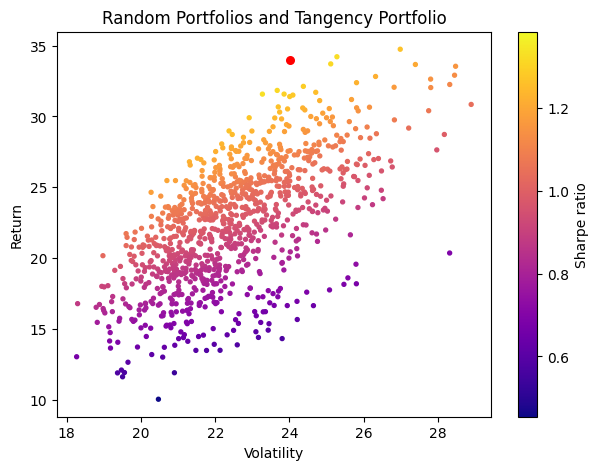

In [756]:
plt.figure(figsize=(7,5))
sc = plt.scatter(
    cloud["vols"], cloud["returns"],
    c=cloud["sharpes"], cmap="plasma", s=8
)
plt.colorbar(sc, label="Sharpe ratio")

# Tangency portfolio as a big red dot
plt.scatter(
    best["vol"], best["return"],
    marker="o", s=30, c="red",  linewidth=1.0
)

plt.xlabel("Volatility")
plt.ylabel("Return")
plt.title("Random Portfolios and Tangency Portfolio")
plt.show()


### What are the weights of your tangency portfolio? 


In [757]:
assets_df = aligned.drop(columns="rf")   # 8 stocks, no sp500

weights_series = pd.Series(best["weights"], index=assets_df.columns).sort_values(ascending=False)

print("Max Sharpe ratio:", round(best["sharpe"], 4))
print("Tangency weights:")
print(weights_series.apply(lambda x: f"{x:.2%}"))

Max Sharpe ratio: 1.384
Tangency weights:
AAPL    30.57%
AMZN    30.04%
TSLA    20.30%
T        7.65%
BA       6.13%
GOOG     2.48%
MGM      2.11%
IBM      0.70%
dtype: object


### What would have been the performance of this portfolio over the sample period? Plot it!

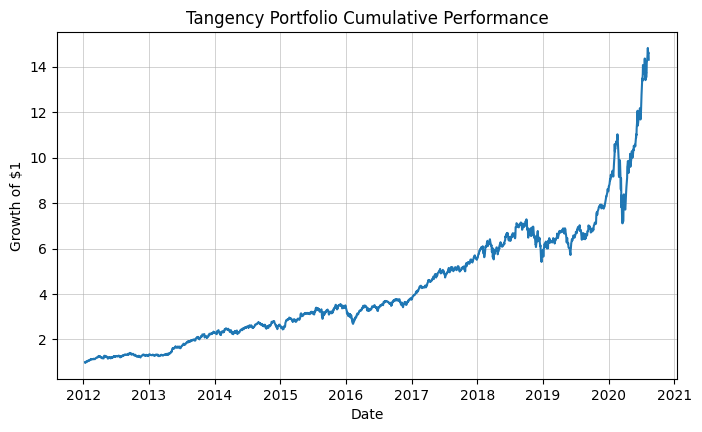

In [758]:
# Make sure weights align with columns
weights = pd.Series(best["weights"], index=assets_df.columns)

# Daily portfolio return in percent are converted to decimal for compounding
tangency_daily_pct = assets_df.mul(weights, axis=1).sum(axis=1)
tangency_daily_dec = tangency_daily_pct / 100.0

cum_growth = (1 + tangency_daily_dec).cumprod()

plt.figure(figsize=(8,4.5))
plt.plot(cum_growth.index, cum_growth.values)
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.title("Tangency Portfolio Cumulative Performance")
plt.grid(True, linewidth=0.4)
plt.show()

### Comparing to a baseline portfolio with equal weights for each stock

In [759]:
periods_per_year = 252

# Same assets as simulate_portfolios 
assets_only = aligned.drop(columns="rf")

rf_annual = aligned["rf"].reindex(assets_only.index).mean()

# Equal-weight portfolio
n = len(assets_only.columns)
ew_w = np.ones(n) / n

mean_ann = assets_only.mean() * periods_per_year
cov_ann  = assets_only.cov()  * periods_per_year

ew_ret    = float(ew_w @ mean_ann.values)
ew_var    = float(ew_w @ cov_ann.values @ ew_w)
ew_vol    = np.sqrt(ew_var)
ew_sharpe = (ew_ret - rf_annual) / ew_vol if ew_vol != 0 else 0.0

print("Equal-weight portfolio metrics (with same rf as tangency):")
print(f"  Return (ann.):  {ew_ret:.4f}")
print(f"  Vol (ann.):     {ew_vol:.4f}")
print(f"  Sharpe (ann.):  {ew_sharpe:.4f}")
print("  Weights:")
for name, w in zip(assets_only.columns, ew_w):
    print(f"    {name}: {w:.2%}")



Equal-weight portfolio metrics (with same rf as tangency):
  Return (ann.):  22.4987
  Vol (ann.):     21.7761
  Sharpe (ann.):  1.0001
  Weights:
    AAPL: 12.50%
    BA: 12.50%
    T: 12.50%
    MGM: 12.50%
    AMZN: 12.50%
    IBM: 12.50%
    TSLA: 12.50%
    GOOG: 12.50%


In [760]:
# 100% S&P 500 portfolio 
sp500_pct = returns_df["sp500"].reindex(assets_only.index)           # align period
sp500_ret_ann = sp500_pct.mean() * periods_per_year
sp500_var_ann = sp500_pct.var()  * periods_per_year
sp500_vol_ann = np.sqrt(sp500_var_ann)
sp500_sharpe  = (sp500_ret_ann - rf_annual) / sp500_vol_ann if sp500_vol_ann != 0 else 0.0

print("\n100% S&P 500 portfolio metrics (same rf):")
print(f"  Return (ann.):  {sp500_ret_ann:.4f}")
print(f"  Vol (ann.):     {sp500_vol_ann:.4f}")
print(f"  Sharpe (ann.):  {sp500_sharpe:.4f}")
print("  Weights:")
print("    sp500: 100.00%")


100% S&P 500 portfolio metrics (same rf):
  Return (ann.):  12.4276
  Vol (ann.):     16.6499
  Sharpe (ann.):  0.7031
  Weights:
    sp500: 100.00%


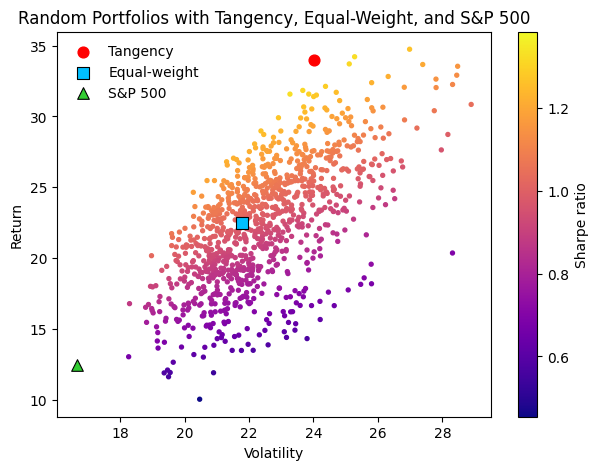

In [761]:
plt.figure(figsize=(7,5))
sc = plt.scatter(
    cloud["vols"], cloud["returns"],
    c=cloud["sharpes"], cmap="plasma", s=8
)
plt.colorbar(sc, label="Sharpe ratio")

# Tangency portfolio (red dot)
plt.scatter(best["vol"], best["return"], marker="o", s=60, c="red", label="Tangency")

# Equal-weight portfolio (blue square)
plt.scatter(ew_vol, ew_ret, marker="s", s=70, c="deepskyblue", edgecolor="k", linewidth=0.8, label="Equal-weight")

# S&P 500 portfolio (green triangle)
plt.scatter(sp500_vol_ann, sp500_ret_ann, marker="^", s=70, c="limegreen", edgecolor="k", linewidth=0.8, label="S&P 500")

plt.xlabel("Volatility")
plt.ylabel("Return")
plt.title("Random Portfolios with Tangency, Equal-Weight, and S&P 500")
plt.legend(frameon=False)
plt.show()


### Optional : Define a function that finds the weights that minimize the variance for all possible level or return (i.e., that draw the efficient frontier). Plot it against the previous scatter plot

In this step we approached portfolio optimization using a numerical method rather than purely analytical formulas, relying on scipy.optimize.minimize with SLSQP to enforce realistic constraints such as fully invested and long-only portfolios. From a coding perspective, we built a function that, for a grid of target returns, minimizes portfolio variance subject to those constraints to trace out the efficient frontier, and separately solved a maximization of the Sharpe ratio to identify the tangency portfolio. From a financial perspective, this corresponds to constructing the set of optimal risk–return portfolios that lie on the frontier and identifying the unique portfolio that maximizes excess return per unit of risk when combined with the risk-free asset. 

Plotting these results alongside simulated random portfolios, the equal-weight benchmark, and the S&P 500 illustrates how constrained optimization produces a smooth efficient frontier, how the tangency portfolio sits exactly where the Capital Market Line touches it, and how the equal weight portfolio benchmark lies below the frontier with inferior risk-adjusted performance. The S&P500 lies on the efficient frontier, confirming that it already represents an efficient allocation within this sample but does not achieve the highest possible Sharpe ratio compared to the tangency portfolio.

In [ ]:
from scipy.optimize import minimize

def min_var_for_target(mu: np.ndarray, Sigma: np.ndarray, target: float):
    """Minimize variance s.t. sum w = 1, w>=0, and w' mu = target."""
    n = len(mu)
    w0 = np.ones(n) / n
    bounds = [(0.0, 1.0)] * n
    cons = (
        {"type": "eq", "fun": lambda w: np.sum(w) - 1.0},                 # fully invested
        {"type": "eq", "fun": lambda w, mu=mu, t=target: w @ mu - t},     # hit target return
    )
    obj = lambda w, S=Sigma: w @ S @ w                                   # minimize variance
    res = minimize(obj, w0, method="SLSQP", bounds=bounds, constraints=cons)
    if not res.success:
        raise RuntimeError(f"SLSQP failed: {res.message}")
    w = res.x
    ret = float(w @ mu)
    vol = float(np.sqrt(w @ Sigma @ w))
    return ret, vol, w

def efficient_frontier_min(mu: np.ndarray, Sigma: np.ndarray, n_points: int = 200):
    """Sweep target returns and build long-only efficient frontier."""
    rmin, rmax = float(mu.min()), float(mu.max())
    targets = np.linspace(rmin, rmax, n_points)
    rets, vols, wts = [], [], []
    for R in targets:
        ret, vol, w = min_var_for_target(mu, Sigma, R)
        rets.append(ret); vols.append(vol); wts.append(w)
    return np.array(rets), np.array(vols), wts, targets

def tangency_long_only(mu: np.ndarray, Sigma: np.ndarray, rf: float):
    """Max Sharpe (long-only, sum w = 1)."""
    n = len(mu)
    w0 = np.ones(n) / n
    bounds = [(0.0, 1.0)] * n
    cons = ({"type": "eq", "fun": lambda w: np.sum(w) - 1.0},)

    def neg_sharpe(w):
        ret = w @ mu
        vol = np.sqrt(w @ Sigma @ w)
        return -(ret - rf) / vol if vol > 0 else 1e6

    res = minimize(neg_sharpe, w0, method="SLSQP", bounds=bounds, constraints=cons)
    if not res.success:
        raise RuntimeError(f"SLSQP tangency failed: {res.message}")
    w = res.x
    ret = float(w @ mu)
    vol = float(np.sqrt(w @ Sigma @ w))
    sharpe = (ret - rf) / vol
    return {"return": ret, "vol": vol, "sharpe": sharpe, "weights": w}

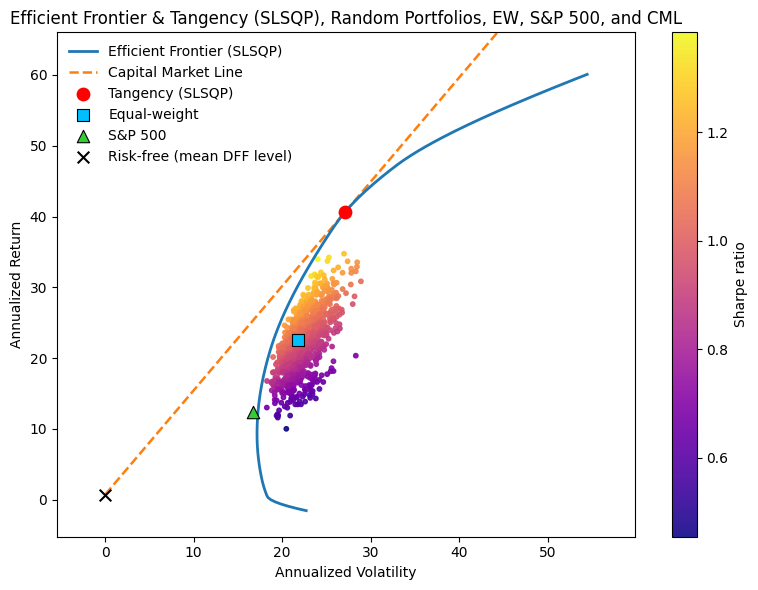

In [765]:
assets_only = aligned.drop(columns="rf")
mean_ann = assets_only.mean() * 252
cov_ann  = assets_only.cov()  * 252

mu = mean_ann.values
Sigma = cov_ann.values

# Risk-free (annual %, no *252)
rf_annual = aligned["rf"].reindex(assets_only.index).mean()

# Efficient frontier (long-only)
ef_rets, ef_vols, ef_wts, ef_targets = efficient_frontier_min(mu, Sigma, n_points=200)

# Tangency via SLSQP
tan = tangency_long_only(mu, Sigma, rf_annual)
cml_slope = tan["sharpe"]

# --- Balanced bounds (symmetric padding) ---
x_lo, x_hi = np.percentile(cloud["vols"], [2, 98])
y_lo, y_hi = np.percentile(cloud["returns"], [2, 98])
x_hi = max(x_hi, tan["vol"], sp500_vol_ann, ew_vol, ef_vols.max())
y_hi = max(y_hi, tan["return"], sp500_ret_ann, ew_ret, ef_rets.max())
x_lo = min(x_lo, 0.0)
y_lo = min(y_lo, rf_annual)
x_pad = 0.10 * (x_hi - x_lo)
y_pad = 0.10 * (y_hi - y_lo)
x_min, x_max = x_lo - x_pad, x_hi + x_pad
y_min, y_max = y_lo - y_pad, y_hi + y_pad

# Capital Market Line
vol_grid = np.linspace(0, x_max, 200)
cml_line = rf_annual + cml_slope * vol_grid

# --- Plot ---
plt.figure(figsize=(8,6))
sc = plt.scatter(cloud["vols"], cloud["returns"], c=cloud["sharpes"], cmap="plasma", s=10, alpha=0.9)
plt.colorbar(sc, label="Sharpe ratio")

plt.plot(ef_vols, ef_rets, lw=2.0, label="Efficient Frontier (SLSQP)", zorder=3)
plt.plot(vol_grid, cml_line, "--", lw=1.8, label="Capital Market Line", zorder=2)

plt.scatter(tan["vol"], tan["return"], marker="o", s=80, c="red", label="Tangency (SLSQP)", zorder=4)
plt.scatter(ew_vol, ew_ret, marker="s", s=80, c="deepskyblue", edgecolor="k", linewidth=0.8, label="Equal-weight", zorder=4)
plt.scatter(sp500_vol_ann, sp500_ret_ann, marker="^", s=80, c="limegreen", edgecolor="k", linewidth=0.8, label="S&P 500", zorder=4)
plt.scatter(0.0, rf_annual, marker="x", s=70, c="black", label="Risk-free (mean DFF level)", zorder=5)

plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.title("Efficient Frontier & Tangency (SLSQP), Random Portfolios, EW, S&P 500, and CML")
plt.legend(frameon=False)
plt.xlim(x_min, x_max); plt.ylim(y_min, y_max)
plt.tight_layout(); plt.show()

## Task #7 : Testing Portfolio Theory - Optional

### Re-run Task #6 but only on the first part of the sample (2012-2016)

In this step, we split the data into a training window (2012–2016) and a testing window (2016–2020) to evaluate the portfolio out-of-sample, comparing the expected performance from the training period against the actual realized return. We used the same function of previous task but with the suggested first part of the sample. 

In [766]:
periods_per_year = 252

assets_all = aligned.drop(columns="rf")
rf_all     = aligned["rf"]

# 1) Train / Test split
train_end = "2015-12-31"
assets_train = assets_all.loc[:train_end]
assets_test  = assets_all.loc["2016-01-01":]

rf_train = rf_all.reindex(assets_train.index)
rf_test  = rf_all.reindex(assets_test.index)

### Find out what are the optimal weights for this period

In [767]:
# Simulation only on first part
best_train, cloud_train = simulate_portfolios(
    assets_train,
    num_portfolios=2000,
    rf_series=rf_train,          
    periods_per_year=periods_per_year
)

w_tan = pd.Series(best_train["weights"], index=assets_train.columns)

# Expected (TRAIN) metrics using those weights
mean_ann_tr = assets_train.mean() * periods_per_year
cov_ann_tr  = assets_train.cov()  * periods_per_year

exp_ret  = float(w_tan @ mean_ann_tr.values)
exp_var  = float(w_tan.values @ cov_ann_tr.values @ w_tan.values)
exp_vol  = float(np.sqrt(exp_var))
rf_ann_tr = rf_train.mean()   # still percent units
exp_sharpe = (exp_ret - rf_ann_tr) / exp_vol if exp_vol != 0 else 0.0

### Simulate your optimal portfolio on the second part of the sample (2016-end)
– How does it perform?
– Plot the expected (measured over the 1st period) vs. the realized return and volatility (over the second).

In [768]:
# 4) Realized (TEST) metrics applying the SAME weights to the test period
port_test_daily_pct = assets_test.mul(w_tan, axis=1).sum(axis=1)

real_ret = float(port_test_daily_pct.mean() * periods_per_year)
real_var = float(port_test_daily_pct.var()  * periods_per_year)
real_vol = float(np.sqrt(real_var))
rf_ann_te = rf_test.mean()
real_sharpe = (real_ret - rf_ann_te) / real_vol if real_vol != 0 else 0.0

# 5) Print summary
print("=== Train period (<= 2015-12-31) Tangency Weights ===")
print(w_tan.sort_values(ascending=False).apply(lambda x: f"{x:.2%}"))
print("\n=== Expected (TRAIN, annualized, percent units) ===")
print(f"Return: {exp_ret:.2f}   Vol: {exp_vol:.2f}   Sharpe (rf=train mean DFF): {exp_sharpe:.3f}")

print("\n=== Realized (TEST, annualized, percent units) ===")
print(f"Return: {real_ret:.2f}   Vol: {real_vol:.2f}   Sharpe (rf=test mean DFF): {real_sharpe:.3f}")

=== Train period (<= 2015-12-31) Tangency Weights ===
GOOG    24.67%
TSLA    21.67%
BA      19.53%
AMZN    16.11%
AAPL    10.38%
MGM      3.78%
T        3.72%
IBM      0.16%
dtype: object

=== Expected (TRAIN, annualized, percent units) ===
Return: 33.61   Vol: 20.47   Sharpe (rf=train mean DFF): 1.637

=== Realized (TEST, annualized, percent units) ===
Return: 29.02   Vol: 27.47   Sharpe (rf=test mean DFF): 1.011


The yearly comparison shows that realized performance often diverges from what was expected based on the training year. This is not surprising: stock returns
are inherently unpredictable and driven by new information. Portfolio weights optimized on past data can therefore look very efficient in-sample but still perform quite differently out-of-sample.

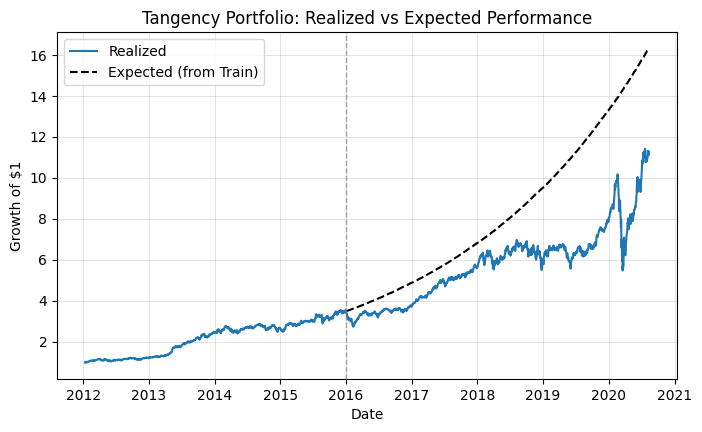

In [769]:
# Portfolio daily returns (train + test) with tangency weights from TRAIN
port_all_daily_pct = assets_all.mul(w_tan, axis=1).sum(axis=1)

# Realized cumulative growth (entire period, backtest + forward test)
real_cum_growth = (1 + port_all_daily_pct/100.0).cumprod()

# Expected growth only applied in TEST window
exp_daily_ret = exp_ret / periods_per_year   
exp_cum_growth = (1 + exp_daily_ret/100.0) ** np.arange(len(assets_test))
exp_cum_growth = pd.Series(exp_cum_growth, index=assets_test.index)

exp_cum_growth *= real_cum_growth.loc[train_end]

# Plot
plt.figure(figsize=(8,4.5))
plt.plot(real_cum_growth.index, real_cum_growth, label="Realized")
plt.plot(exp_cum_growth.index, exp_cum_growth, "--", label="Expected (from Train)", color="black")
plt.axvline(pd.to_datetime(train_end), color="gray", linestyle="--", lw=1, alpha=0.7)
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.title("Tangency Portfolio: Realized vs Expected Performance")
plt.legend()
plt.grid(True, linewidth=0.4, alpha=0.6)
plt.show()



This chart compares the expected growth of the tangency portfolio (based on the training period 2012–2015) with the realized performance in the test period (2016–2020). The dashed line shows the projection implied by historical averages, which assumes smooth compounding and stable risk-return trade-offs. The solid line, however, reveals the realized growth path, which is far more volatile and consistently lags the forecast. This gap illustrates the key challenge of portfolio optimization, the models cannot fully capture market shocks, for example the 2020 pandemic.

### Super optional : Let’s go a step further. Every year, you re-balance your portfolio based on last year data. What is your performance overall?

In [770]:
# Annual Rebalancing
periods_per_year = 252

assets_all = aligned.drop(columns="rf")
rf_all     = aligned["rf"]

start_all = "2012-01-12"
end_all   = "2020-08-11"
assets_all = assets_all.loc[start_all:end_all]
rf_all     = rf_all.loc[start_all:end_all]

invest_years = list(range(2013, 2021))

daily_series = []
per_year_weights = []  
per_year_stats = []  
for y in invest_years:
    train_year = y - 1
    tr_start, tr_end = f"{train_year}-01-01", f"{train_year}-12-31"
    te_start, te_end = f"{y}-01-01", f"{y}-12-31"
    if y == 2020:
        te_end = end_all

    assets_train = assets_all.loc[tr_start:tr_end]
    assets_test  = assets_all.loc[te_start:te_end]
    rf_train = rf_all.reindex(assets_train.index)

    if len(assets_train) < 50 or len(assets_test) < 20:
        continue

    # Optimize on prior year
    best_train, _ = simulate_portfolios(
        assets_train, num_portfolios=2000, rf_series=rf_train, periods_per_year=periods_per_year
    )
    w_tan = pd.Series(best_train["weights"], index=assets_train.columns)

    # Expected (from TRAIN year)
    mean_ann_tr = assets_train.mean() * periods_per_year
    cov_ann_tr  = assets_train.cov()  * periods_per_year
    exp_ret = float(w_tan @ mean_ann_tr.values)
    exp_vol = float(np.sqrt(w_tan.values @ cov_ann_tr.values @ w_tan.values))

    # Realized (in TEST year) 
    port_test_daily_pct = assets_test.mul(w_tan, axis=1).sum(axis=1)
    real_ret = float(port_test_daily_pct.mean() * periods_per_year)
    real_vol = float(np.sqrt(port_test_daily_pct.var() * periods_per_year))

    w_nonzero = w_tan[w_tan.abs() > 1e-6].reindex(w_tan.abs().sort_values(ascending=False).index).dropna()
    weights_str = ", ".join(f"{t}={w:.2%}" for t, w in w_nonzero.items())
    print(f"\n{y} new weights: {weights_str}")

    print(
        f"{y} expected vs realized — "
        f"Returns: {exp_ret:.2f} vs {real_ret:.2f} (delta: {real_ret - exp_ret:+.2f}); "
        f"Volatility: {exp_vol:.2f} vs {real_vol:.2f} (delta: {real_vol - exp_vol:+.2f})"
    )

    per_year_weights.append((y, w_tan.copy()))
    daily_series.append(port_test_daily_pct)

    
    per_year_stats.append({
        "year": y, "weights": w_tan.copy(),
        "exp_ret": exp_ret, "exp_vol": exp_vol,
        "real_ret": real_ret, "real_vol": real_vol
    })


# Overall realized performance

port_all_daily_pct = pd.concat(daily_series).sort_index()

real_ret_all = float(port_all_daily_pct.mean() * periods_per_year)
real_var_all = float(port_all_daily_pct.var()  * periods_per_year)
real_vol_all = float(np.sqrt(real_var_all))

rf_invest = rf_all.reindex(port_all_daily_pct.index)
rf_ann_all = rf_invest.mean() 
real_sharpe_all = (real_ret_all - rf_ann_all) / real_vol_all if real_vol_all != 0 else 0.0

print(f"\nOverall realized (2013–2020 up to 2020-08-11): "
        f"Return {real_ret_all:.2f}  Vol {real_vol_all:.2f}  Sharpe {real_sharpe_all:.3f}")




2013 new weights: AMZN=25.82%, T=22.76%, AAPL=17.62%, GOOG=17.52%, IBM=8.01%, TSLA=4.66%, MGM=1.99%, BA=1.62%
2013 expected vs realized — Returns: 23.49 vs 34.74 (delta: +11.25); Volatility: 16.53 vs 13.79 (delta: -2.74)

2014 new weights: BA=24.38%, MGM=23.74%, GOOG=22.75%, TSLA=13.54%, AAPL=12.66%, T=1.09%, AMZN=0.97%, IBM=0.88%
2014 expected vs realized — Returns: 68.77 vs 8.08 (delta: -60.69); Volatility: 17.53 vs 18.64 (delta: +1.11)

2015 new weights: AAPL=47.55%, TSLA=13.99%, GOOG=10.41%, BA=9.81%, IBM=5.74%, AMZN=4.53%, MGM=4.20%, T=3.79%
2015 expected vs realized — Returns: 20.68 vs 10.83 (delta: -9.85); Volatility: 17.17 vs 20.85 (delta: +3.67)

2016 new weights: AMZN=38.34%, BA=17.64%, TSLA=12.62%, GOOG=8.91%, IBM=8.65%, T=7.57%, MGM=4.95%, AAPL=1.31%
2016 expected vs realized — Returns: 39.63 vs 12.38 (delta: -27.25); Volatility: 21.52 vs 18.89 (delta: -2.63)

2017 new weights: T=47.25%, AAPL=30.23%, IBM=10.31%, AMZN=6.19%, MGM=3.92%, BA=1.60%, TSLA=0.49%, GOOG=0.02%
2017 

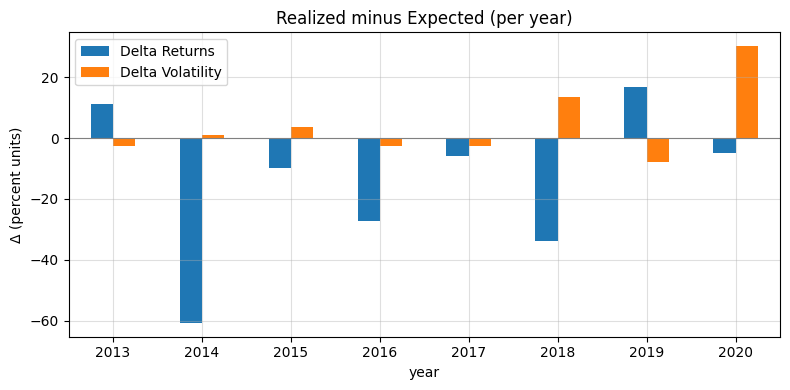

In [771]:
per_year_df = pd.DataFrame(per_year_stats).set_index("year").sort_index()

# Bar chart: realized - expected 
deltas = pd.DataFrame({
    "Delta Returns": per_year_df["real_ret"] - per_year_df["exp_ret"],
    "Delta Volatility": per_year_df["real_vol"] - per_year_df["exp_vol"],
})
deltas.plot(kind="bar", figsize=(8,4), rot=0)
plt.axhline(0, color="gray", linewidth=0.8)
plt.title("Realized minus Expected (per year)")
plt.ylabel("Δ (percent units)")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

The bar chart highlights that realized returns are frequently lower than expected, while volatility is often higher. This illustrates the practical limits of portfolio optimization: in-sample results may look strong, but out-of-sample reality tends to be more volatile and less rewarding.


In [772]:
# Portfolio weights per year
all_assets = list(assets_all.columns)

weights_by_asset = pd.DataFrame({
    row["year"]: row["weights"].reindex(all_assets).fillna(0.0)
    for row in per_year_stats
}).sort_index(axis=1)  

vmax = float(np.abs(weights_by_asset.values).max())

display(
    weights_by_asset
        .style
        .format("{:.2%}")
        .background_gradient(cmap="coolwarm", vmin=-vmax, vmax=vmax, axis=None)
        .set_table_styles([{"selector": "th.col_heading", "props": [("text-align","right")]}])
)

,2013,2014,2015,2016,2017,2018,2019,2020
AAPL,17.62%,12.66%,47.55%,1.31%,30.23%,14.23%,11.57%,43.02%
BA,1.62%,24.38%,9.81%,17.64%,1.60%,35.40%,3.53%,8.19%
T,22.76%,1.09%,3.79%,7.57%,47.25%,8.47%,4.13%,34.38%
MGM,1.99%,23.74%,4.20%,4.95%,3.92%,0.16%,1.61%,2.59%
AMZN,25.82%,0.97%,4.53%,38.34%,6.19%,27.57%,30.93%,0.07%
IBM,8.01%,0.88%,5.74%,8.65%,10.31%,0.96%,1.02%,2.75%
TSLA,4.66%,13.54%,13.99%,12.62%,0.49%,7.58%,30.56%,8.57%
GOOG,17.52%,22.75%,10.41%,8.91%,0.02%,5.63%,16.64%,0.43%


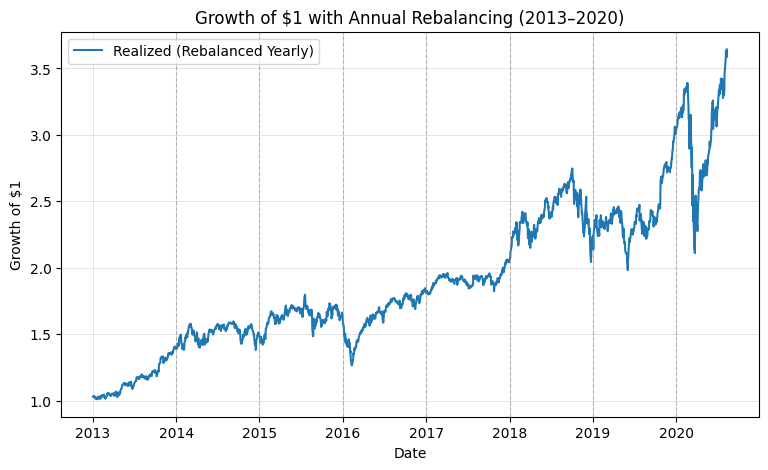

In [773]:
# Cumulative growth chart
cum_growth = (1 + port_all_daily_pct/100.0).cumprod()
plt.figure(figsize=(9,5))
plt.plot(cum_growth.index, cum_growth, label="Realized (Rebalanced Yearly)")
for y in invest_years:
    x = pd.to_datetime(f"{y}-01-01")
    if x >= cum_growth.index.min() and x <= cum_growth.index.max():
        plt.axvline(x, color="gray", linestyle="--", lw=0.8, alpha=0.5)
plt.title("Growth of $1 with Annual Rebalancing (2013–2020)")
plt.xlabel("Date"); plt.ylabel("Growth of $1")
plt.grid(True, linewidth=0.4, alpha=0.6)
plt.legend()
plt.show()

### Comparison to the single rebalancing done in part 6b

In [774]:
cmp_start, cmp_end = "2016-01-01", "2020-08-11"
cum_single = real_cum_growth.loc[cmp_start:cmp_end]
cum_rebal  = cum_growth.loc[cmp_start:cmp_end]

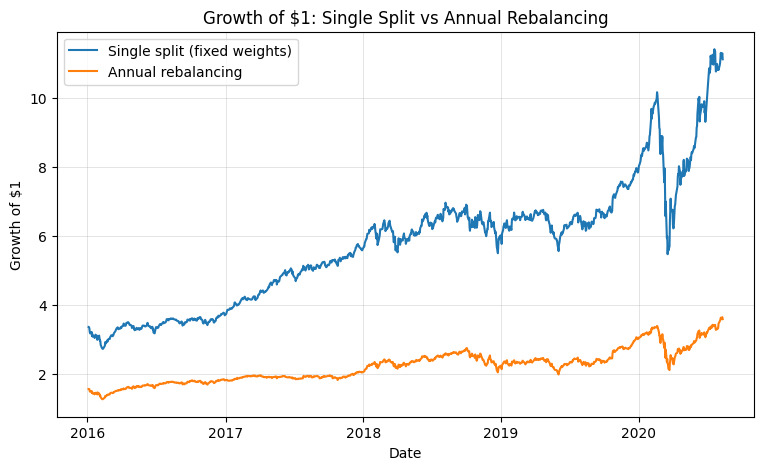

=== Terminal value comparison (2016–2020-08-11) ===
Single split:        11.124
Annual rebalancing:  3.588
Difference:          -7.536


In [775]:
plt.figure(figsize=(9,5))
plt.plot(cum_single.index, cum_single, label="Single split (fixed weights)")
plt.plot(cum_rebal.index,  cum_rebal,  label="Annual rebalancing")
plt.title("Growth of $1: Single Split vs Annual Rebalancing")
plt.xlabel("Date"); plt.ylabel("Growth of $1")
plt.grid(True, linewidth=0.4, alpha=0.6)
plt.legend()
plt.show()

print("=== Terminal value comparison (2016–2020-08-11) ===")
print(f"Single split:        {cum_single.iloc[-1]:.3f}")
print(f"Annual rebalancing:  {cum_rebal.iloc[-1]:.3f}")
print(f"Difference:          {cum_rebal.iloc[-1] - cum_single.iloc[-1]:+.3f}")

Comparing the single train/test split with annual rebalancing highlights a clear trade-off. The fixed-weight portfolio achieved higher terminal growth, while the rebalanced strategy lagged. This reflects the fact that markets are inherently unpredictable: rebalancing each year means frequently shifting weights based on noisy past data, which can lead to worse outcomes than simply holding a stable portfolio.
